##### **获取 irap zip 文件包, to get fileparam.yml**

In [1]:
import io
import os
import zipfile
import requests
import yaml
import pandas as pd
from astropy.io import fits
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from astropy.table import Table
import numpy as np
import re, os, gzip
from io import BytesIO
from datetime import datetime
from bs4 import BeautifulSoup
from sunpy.map import Map
from astropy.time import Time
from sunpy.coordinates import get_earth
from astropy import units as u

from sunpy.coordinates import HeliographicCarrington, HeliographicStonyhurst, RotatedSunFrame
from astropy.coordinates import SkyCoord
from astropy import units as u

import matplotlib.pyplot as plt

In [2]:
BASE_URL = "https://connect-tool.irap.omp.eu"
R_SUN_M  = 6.957e8   # solar radius in metres
AU_M     = 1.496e11  # 1 AU in metres



def build_zip_url(sc: str, coronal: str, mode: str,
                  date_str: str, time_str: str) -> str:
    """
    Construct the direct download URL for an MCT result ZIP.

    ZIP naming convention (confirmed from live API):
        {SC}_PARKER_PFSS_{MODE}_{CORONAL}_SCIENCE_{YYYYMMDD}T{HHMMSS}.zip

    Parameters
    ----------
    sc      : spacecraft, e.g. 'SOLO', 'PSP', 'EARTH', 'STA', 'BEPI'
    coronal : coronal model, e.g. 'ADAPT', 'WSO', 'NSO'
    mode    : propagation mode, e.g. 'SCTIME', 'SUNTIME', 'SCTIMEBW', 'SUNTIMEBW'
    date_str: 'YYYY-MM-DD'
    time_str: 'HHMMSS' - one of 000000, 060000, 120000, 180000
    """
    date_compact = date_str.replace("-", "")
    fname = f"{sc}_PARKER_PFSS_{mode}_{coronal}_SCIENCE_{date_compact}T{time_str}.zip"
    return f"{BASE_URL}/static/zip_files/{fname}"

def build_api_url(sc: str, coronal: str, mode: str, date_str: str, time_str: str) -> str:
    """Fallback URL via the MCT API endpoint."""
    return f"{BASE_URL}/api/{sc}/{coronal}/PARKER/{mode}/{date_str}/{time_str}"


def fetch_mct_zip(sc: str, coronal: str, mode: str, date_str: str, time_str: str, timeout: int = 60) -> dict[str, bytes]:
    urls_to_try = [
        build_zip_url(sc, coronal, mode, date_str, time_str),
        build_api_url(sc, coronal, mode, date_str, time_str),
    ]

    for url in urls_to_try:
        print(f"Fetching ZIP: {url}")
        resp = requests.get(url, timeout=timeout, allow_redirects=True)
        resp.raise_for_status()

        try:
            files: dict[str, bytes] = {}
            with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
                for name in zf.namelist():
                    files[name] = zf.read(name)
            print(f"  => {len(files)} files in ZIP")
            return files
        except zipfile.BadZipFile:
            print(f"  => Not a valid ZIP, trying next URL ...")

    raise RuntimeError(f"Failed to download a valid ZIP for {sc} {coronal} {mode} {date_str} {time_str}")


def get_ascii_text(files: dict, keyword: str) -> bytes | None:
    """Return the bytes of the first ZIP entry whose name contains `keyword`."""
    for name, content in files.items():
        if keyword in name.lower():
            return content
    return None

In [73]:
# ── Configuration ────────────────────────────────────────────────────────────
SC      = "SOLO"
CORONAL = "ADAPT"
MODE    = "SUNTIME"   # propagation mode
DATE    = "2022-03-03"
TIME    = "120000"
# ─────────────────────────────────────────────────────────────────────────────
save_dir = f'../results/IRAP_results/{DATE}/'
os.makedirs(save_dir, exist_ok=True)
save_fig = False

# 1. ZIP download (connectivity, HCS, params, images)
mct_files = fetch_mct_zip(SC, CORONAL, MODE, DATE, TIME)

print("\nFiles in ZIP:")
for name in sorted(mct_files):
    size = len(mct_files[name])
    print(f"  {name}  ({size:,} bytes)")


Fetching ZIP: https://connect-tool.irap.omp.eu/static/zip_files/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000.zip


  => 18 files in ZIP

Files in ZIP:
  SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_backgroundeuv171.png  (140,032 bytes)
  SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_backgroundeuv193.png  (207,405 bytes)
  SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_backgroundeuv304.png  (3,075 bytes)
  SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_backgroundmag.png  (77,647 bytes)
  SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_backgroundwl.png  (85,287 bytes)
  SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_filear.json  (3,523 bytes)
  SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_fileconnectivity.ascii  (9,790 bytes)
  SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_fileevent.ascii  (554 bytes)
  SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_filehcs.ascii  (50,686 bytes)
  SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_fileparam.yml  (1,802 bytes)
  SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_layer

##### **读取 fileparam.yml**

- 文件包含了 `position_sc`, `position_ss`, `realization_adapt`, and addresses of 2D coronal images, etc.
- 返回:
    - `params`: fileparam.yml 内的主要信息
    - `field_line_df`: SC/Footpoints positions

In [74]:
def parse_params(content: bytes) -> dict:
    """
    Parse *_fileparam.yml.

    Position values in _fileparam.yml are in km:
        photosphere       = 695700 km  = 1.0 Rsun
        source surface    = 1739250 km = 2.5 Rsun
    Format: [R_km, lon_HGC_deg (CRLN), lat_HGC_deg (CRLT)]
    """
    text = content.decode("utf-8", errors="ignore")
    yaml_data = yaml.safe_load(text)
    spacecraft_name = next(iter(yaml_data))       # e.g. 'SOLO'
    spacecraft_data = yaml_data[spacecraft_name]

    R_SUN_KM = R_SUN_M / 1000   # 695700 km
    AU_KM    = AU_M    / 1000   # 149600000 km

    def parse_position(position_list):
        if position_list is None:
            return None
        radius_km = position_list[0]
        return {
            "R_km":        radius_km,
            "R_AU":        radius_km / AU_KM,
            "R_Rsun":      radius_km / R_SUN_KM,
            "lon_HGC_deg": position_list[1],   # CRLN
            "lat_HGC_deg": position_list[2],   # CRLT
        }

    result = {
        "sc_name": spacecraft_name,
        "sc_position": parse_position(spacecraft_data.get("position_sc")),
        "source_surface_footpoints": {
            stream_name: parse_position(position_list)
            for stream_name, position_list in (spacecraft_data.get("position_ss") or {}).items()
            if position_list is not None
        },
        "photospheric_footpoints": {
            stream_name: parse_position(position_list)
            for stream_name, position_list in (spacecraft_data.get("main_connect_point") or {}).items()
            if position_list is not None
        },
        "metadata": {
            "date_insitu":          str(spacecraft_data.get("date_in", "")),
            "date_surf":           str(spacecraft_data.get("date_surf", "")),
            "coronal_model":       spacecraft_data.get("cmodel"),
            "mag_input":           spacecraft_data.get("magtype"),
            "realization_adapt":   spacecraft_data.get("realization_adapt"),
            "helio_model":         spacecraft_data.get("hmodel"),
            "source_surface_Rsun": spacecraft_data.get("rss"),
            "polarity":            spacecraft_data.get("polarity", {}),
            "vhelio_km_s":         spacecraft_data.get("vhelio", {}),
            "reliability_score":   spacecraft_data.get("score"),
        },
    }
    return result

def extract_key_positions(params: dict) -> pd.DataFrame:
    """
    Assemble a 3-point summary table: SC -> Source Surface -> Photosphere.
    For the actual curved PFSS trace use parse_fieldlines_json().
    """
    rows = []

    # sc position
    sc_dict = params['sc_position']
    rows.append({
        "segment":     params['sc_name'],
        "sw_type":     None,
        "R_AU":        sc_dict.get("R_AU"),
        "R_Rsun":      sc_dict.get("R_Rsun"),
        "lon_HGC_deg": sc_dict["lon_HGC_deg"],
        "lat_HGC_deg": sc_dict["lat_HGC_deg"],
    })
    for sw, vals in params["source_surface_footpoints"].items():
        rows.append({
            "segment":     "Source-Surface Footpoint",
            "sw_type":     sw,
            "R_AU":        vals.get("R_AU"),
            "R_Rsun":      vals.get("R_Rsun"),
            "lon_HGC_deg": vals["lon_HGC_deg"],
            "lat_HGC_deg": vals["lat_HGC_deg"],
        })
    for sw, vals in params["photospheric_footpoints"].items():
        rows.append({
            "segment":     "Photospheric Footpoint",
            "sw_type":     sw,
            "R_AU":        vals.get("R_AU"),
            "R_Rsun":      vals.get("R_Rsun"),
            "lon_HGC_deg": vals["lon_HGC_deg"],
            "lat_HGC_deg": vals["lat_HGC_deg"],
        })
    return pd.DataFrame(rows)

params = parse_params(get_ascii_text(mct_files, "fileparam"))
df_position_sc_ss_solar = extract_key_positions(params)

In [75]:
df_position_sc_ss_solar

,segment,sw_type,R_AU,R_Rsun,lon_HGC_deg,lat_HGC_deg
0,SOLO,None,0.545599,117.323082,46.684068,-4.151656
1,Source-Surface Footpoint,M,0.011626,2.500000,71.045084,-4.151656
2,Photospheric Footpoint,M,0.004650,1.000000,47.932840,-14.203784


##### **读取 IRAP footpoints**
依赖 IRAP MCT 网页的参数，如果官网参数修改，则必须更新参数保持准确。

In [76]:
# ── Radio-button ID maps (confirmed from live page DOM) ─────────────────────
_MODE_RADIO_ID = {
    "SUNTIME":   "reftime2-0",
    "SCTIME":    "reftime2-1",
    "SUNTIMEBW": "reftime2-2",
    "SCTIMEBW":  "reftime2-3",
}
_TIME_RADIO_ID = {
    "000000": "time-0",
    "060000": "time-1",
    "120000": "time-2",
    "180000": "time-3",
}
_ALL_CORONAL_IDS = ("wso", "nso", "adapt")

# Directly get files from IRAP MCT
def trigger_mct_and_get_urls(sc: str = "SOLO",coronal: str = "ADAPT",mode: str = "SUNTIME",date: str = "2022-03-03",
                             time: str = "120000",timeout: int = 120) -> dict:
    """
    Open the IRAP MCT website in headless Chrome, fill the form for the
    requested parameters, submit it, and wait for the server-side PFSS
    computation to complete.

    The fieldline FITS file only becomes available on the server AFTER
    the web form has been submitted for a given date/time/parameters.
    This function automates that step and returns the real download URLs.

    Parameters
    ----------
    sc      : spacecraft code ('SOLO', 'PSP', 'STA', 'EARTH', 'BEPI', 'JUICE')
    coronal : coronal model  ('WSO', 'NSO', 'ADAPT')
    mode    : propagation mode ('SUNTIME', 'SCTIME', 'SUNTIMEBW', 'SCTIMEBW')
    date    : ISO date string 'YYYY-MM-DD'
    time    : time string 'HHMMSS'  ('000000', '060000', '120000', '180000')
    timeout : max seconds to wait for computation result (default 120 s)

    Returns
    -------
    dict with keys: 'fieldline_fits', 'connectivity_ascii', 'hcs_ascii'
    """
    opts = Options()
    opts.binary_location = "/usr/bin/google-chrome"
    opts.add_argument("--headless=new")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("--disable-gpu")
    opts.add_argument("--window-size=1920,1080")

    driver = webdriver.Chrome(options=opts)
    wait = WebDriverWait(driver, timeout)

    try:
        driver.get(BASE_URL)

        # 1. Ensure only the requested coronal model checkbox is selected
        for cb_id in _ALL_CORONAL_IDS:
            cb = driver.find_element(By.ID, cb_id)
            if cb.get_attribute("disabled"):
                continue
            want = (cb_id == coronal.lower())
            if cb.is_selected() != want:
                cb.click()

        # 2. Select propagation mode radio button
        mode_radio = driver.find_element(By.ID, _MODE_RADIO_ID[mode])
        if not mode_radio.is_selected():
            mode_radio.click()

        # 3. Set date via JavaScript (send_keys is unreliable for type="date" in headless Chrome)
        date_input = driver.find_element(By.ID, "date")
        driver.execute_script(
            "arguments[0].value = arguments[1];"
            "arguments[0].dispatchEvent(new Event('change', {bubbles: true}));",
            date_input, date,
        )

        # 4. Select time radio button
        time_radio = driver.find_element(By.ID, _TIME_RADIO_ID[time])
        if not time_radio.is_selected():
            time_radio.click()

        # 5. Submit the form — triggers server-side PFSS computation
        driver.find_element(By.ID, "submit").click()

        # Build the datetime token used in every filename: YYYYMMDDTHHMMSS
        dt = date.replace("-", "") + "T" + time   # e.g. "20220304T120000"
        stem_prefix = f"{sc}_PARKER_PFSS_{mode}_{coronal}"

        # 6. Wait for the FITS link with the exact SC/mode/coronal/datetime to appear.
        #    The full stem (SC_PARKER_PFSS_{MODE}_{CORONAL}_*_{DT}) is unique, so
        #    matching both the prefix and the datetime avoids hitting stale/cached links.
        fits_xpath = (
            f"//a[contains(@href, '{stem_prefix}') "
            f"and contains(@href, '{dt}') "
            f"and contains(@href, '_filefieldline.fits')]"
        )
        fits_elem = wait.until(EC.presence_of_element_located((By.XPATH, fits_xpath)))
        fits_url = fits_elem.get_attribute("href")   # Selenium returns full absolute URL

        # 7. Extract connectivity and HCS URLs (same stem, different suffix)
        conn_elem = driver.find_element(
            By.XPATH,
            f"//a[contains(@href, '{stem_prefix}') "
            f"and contains(@href, '{dt}') "
            f"and contains(@href, '_fileconnectivity.ascii')]",
        )
        conn_url = conn_elem.get_attribute("href")

        hcs_elem = driver.find_element(
            By.XPATH,
            f"//a[contains(@href, '{stem_prefix}') "
            f"and contains(@href, '{dt}') "
            f"and contains(@href, '_filehcs.ascii')]",
        )
        hcs_url = hcs_elem.get_attribute("href")

        print(f"Fieldline FITS : {fits_url}")
        print(f"Connectivity   : {conn_url}")
        print(f"HCS            : {hcs_url}")

        return {
            "fieldline_fits":      fits_url,
            "connectivity_ascii":  conn_url,
            "hcs_ascii":           hcs_url,
        }

    finally:
        driver.quit()

def _get(url: str, timeout: int = 60) -> requests.Response:
    r = requests.get(url, timeout=timeout) # fetch files from Irap MCT, and store data in memory instead of disk
    r.raise_for_status()
    return r

def fetch_fieldline_fits(urls: dict) -> fits.HDUList:
    """Read fieldline FITS directly into memory (no local file)."""
    r = _get(urls["fieldline_fits"])
    if r.content[:6] != b"SIMPLE":
        raise ValueError(
            f"Response from {urls['fieldline_fits']!r} is not a valid FITS file "
            "(server returned HTML instead of binary data). "
            "Call trigger_mct_and_get_urls() first to trigger the computation."
        )
    return fits.open(io.BytesIO(r.content))

def fetch_connectivity(urls: dict) -> io.StringIO:
    """Fetch connectivity ASCII and return as StringIO buffer."""
    r = _get(urls["connectivity_ascii"])
    return io.StringIO(r.text)

def fetch_hcs(urls: dict) -> io.StringIO:
    """Fetch HCS ASCII and return as StringIO buffer."""
    r = _get(urls["hcs_ascii"])
    return io.StringIO(r.text)

# ── Column rename map: file header names → pandas-friendly names ─────────────
# Keys that contain special characters or differ from downstream column names
# are mapped here.  All other column names (e.g. 'i') pass through unchanged.
_CONN_COL_RENAME = {
    "SSW/FSW/M":      "type",
    "density(%)":     "prob",
    "CRLT(degrees)":  "lat_CR",
    "CRLN(degrees)":  "lon_CR",
    "R(m)":           "R_m",
    "DIST(m)":        "DIST_m",
    "HPLT(degrees)":  "HPLT_deg",
    "HPLN(degrees)":  "HPLN_deg",
}
def _clean_hdr_key(k: str) -> str:
    """Sanitise a header format-spec token into a valid column name."""
    return k.replace("(m)", "_m").replace("(degrees)", "_deg")

def parse_connectivity(buf) -> tuple:
    """
    Parse *_fileconnectivity.ascii from a file path or StringIO buffer.

    Anchors on '#Data is formatted as follow:' to map format-spec lines
    to data lines without relying on fixed line indices.

    Returns
    -------
    comments  : list of str       — all '#'-prefixed header lines (raw)
    header_df : pd.DataFrame      — single-row metadata table with columns:
                  nVersion, Rsun_m, ObserverTime,
                  ObserverName, R_OBS_m, CRLT_OBS_deg, CRLN_OBS_deg,
                  npoint_tot, npoint_ssw, npoint_fsw, npoint_m
    conn_df   : pd.DataFrame      — footpoint rows with columns:
                  type, i, prob, R_m, lat, lon, DIST_m, HPLT_deg, HPLN_deg
    """
    # ── pass 1: separate comment and data lines ───────────────────────────────
    comments   = []
    data_lines = []
    for ln in buf:
        stripped = ln.rstrip("\n")
        if not stripped.strip():
            continue
        if stripped.strip().startswith("#"):
            comments.append(stripped.strip())
        else:
            data_lines.append(stripped.strip())

    # ── pass 2: locate '#Data is formatted as follow:' anchor ────────────────
    anchor_idx = None
    for i, cl in enumerate(comments):
        if "Data is formatted as follow" in cl:
            anchor_idx = i + 1
            break
    if anchor_idx is None:
        raise ValueError(
            "Could not find '#Data is formatted as follow:' in file header. "
            "File format may have changed."
        )

    # ── pass 3: collect format-spec lines after the anchor ───────────────────
    # All # lines up to (but not including) the '#SSW/FSW/M …' column-header line
    # are metadata specs; the '#SSW/FSW/M …' line defines connectivity columns.
    fmt_spec_lines  = []   # e.g. ['nVersion', 'Rsun(m)', 'ObserverTime', ...]
    col_header_line = None
    for cl in comments[anchor_idx:]:
        content = cl.lstrip("#").strip()
        if content.startswith("SSW/FSW/M") or (
            "SSW" in content and "FSW" in content and "density" in content
        ):
            col_header_line = content
            break
        fmt_spec_lines.append(content)

    if col_header_line is None:
        raise ValueError(
            "Could not find the '#SSW/FSW/M …' column-header line. "
            "File format may have changed."
        )

    # ── pass 4: zip format-spec lines with data_lines → header_dict ──────────
    # Special case: a single format-spec key paired with multiple data tokens
    # (e.g. 'ObserverTime' → '2022-03-03 12:00:00') — join all tokens.
    header_dict = {}
    for fmt_line, data_line in zip(fmt_spec_lines, data_lines):
        keys = fmt_line.split()
        vals = data_line.split()
        if len(keys) == 1 and len(vals) > 1:
            header_dict[_clean_hdr_key(keys[0])] = " ".join(vals)
        else:
            for k, v in zip(keys, vals):
                header_dict[_clean_hdr_key(k)] = v

    # ── pass 5: build header_df ───────────────────────────────────────────────
    header_df = pd.DataFrame([header_dict])

    # ── pass 6: slice connectivity data rows using npoint_tot ─────────────────
    n_meta    = len(fmt_spec_lines)
    npoint_tot = int(data_lines[n_meta - 1].split()[0])   # first token of npoint line. i.e., connectivity points total number
    conn_rows  = data_lines[n_meta : n_meta + npoint_tot]

    if len(conn_rows) != npoint_tot:
        raise ValueError(
            f"Expected {npoint_tot} connectivity rows but found {len(conn_rows)}."
        )

    # ── pass 7: build conn_df with renamed columns and numeric types ──────────
    raw_cols = col_header_line.split()                    # names from file header
    renamed  = [_CONN_COL_RENAME.get(c, c) for c in raw_cols]

    conn_df = pd.DataFrame(
        [row.split() for row in conn_rows],
        columns=renamed,
    )
    # Cast numeric columns to float (type and i remain str/int)
    float_cols = [c for c in renamed if c not in ("type", "i")]
    for col in float_cols:
        conn_df[col] = conn_df[col].astype(float)
    conn_df["i"] = conn_df["i"].astype(int)

    return comments, header_df, conn_df


In [77]:
# Step 1: open MCT in headless Chrome, fill the form, trigger server-side
#         PFSS computation, and return the real download URLs.
#         This handles SCIENCE / EXTENDED / FORECAST path automatically.
urls = trigger_mct_and_get_urls(sc=SC, coronal=CORONAL, mode=MODE, date=DATE, time=TIME)

# Step 2: download all files using the URLs confirmed by the browser
fieldline_fits   = fetch_fieldline_fits(urls)    # astropy HDUList (FITS in memory)
connectivity_ascii = fetch_connectivity(urls)       # StringIO of *_fileconnectivity.ascii
hcs_ascii          = fetch_hcs(urls)               # StringIO of *_filehcs.ascii

print("All files fetched successfully.\n")

comments, header_df, foot_solarsurf_df = parse_connectivity(connectivity_ascii)

# Derive sc_info dict for backward compatibility with plot functions
# sc_info = {
#     "name": header_df["ObserverName"].iloc[0],
#     "time": header_df["ObserverTime"].iloc[0],
#     "R_m":  float(header_df["R_OBS_m"].iloc[0]),
#     "lat":  float(header_df["CRLT_OBS_deg"].iloc[0]),
#     "lon":  float(header_df["CRLN_OBS_deg"].iloc[0]),
# }
# print("SC:", sc_info)
# print(f"Footpoints: {len(footpoints_df)} rows")

Fieldline FITS : https://connect-tool.irap.omp.eu/static/temporary/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_filefieldline.fits
Connectivity   : https://connect-tool.irap.omp.eu/static/data/connect_tool/PARKER/PFSS/SUNTIME/SCIENCE/SOLO_ADAPT_20220303T120000/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_fileconnectivity.ascii
HCS            : https://connect-tool.irap.omp.eu/static/connect_img/PARKER/PFSS/SUNTIME/SCIENCE/SOLO_ADAPT_20220303T120000/SOLO_PARKER_PFSS_SUNTIME_ADAPT_SCIENCE_20220303T120000_filehcs.ascii
All files fetched successfully.



In [78]:
RSUN_KM = 695700.0
REQUIRED_COLS = ["curv", "r", "lon", "lat", "br", "blon", "blat"]

def parse_fieldline_fits(source):
    """
    Parse MCT fieldline FITS.

    Parameters
    ----------
    source : astropy HDUList (already in memory) OR a file path / URL string.

    Returns
    -------
    DataFrame with columns: curv, r_km, R_Rsun, lon_HGC_deg, lat_HGC_deg,
                             br, blon, blat
    """
    if isinstance(source, fits.HDUList):
        hdul = source
        close_after = False
    else:
        hdul = fits.open(source)
        close_after = True

    try:
        # Scan for the first BinTableHDU whose columns contain the fieldline data
        tab = None
        for hdu in hdul:
            if not isinstance(hdu, (fits.BinTableHDU, fits.TableHDU)):
                continue
            if hdu.data is None:
                continue
            names = [c.name.lower() for c in hdu.columns]
            if all(c in names for c in REQUIRED_COLS):
                tab = Table(hdu.data).to_pandas()
                break
        if tab is None:
            raise RuntimeError(
                f"No HDU with columns {REQUIRED_COLS} found in fieldline FITS."
            )
    finally:
        if close_after:
            hdul.close()

    _RSUN_KM = 695700.0  # km per solar radius (local, avoids scoping issues)
    return pd.DataFrame({
        "curv":        tab["curv"].astype(float),
        "r_km":        tab["r"].astype(float),
        "R_Rsun":      tab["r"].astype(float) / _RSUN_KM,
        "lon_HGC_deg": np.mod(tab["lon"].astype(float), 360.0),
        "lat_HGC_deg": tab["lat"].astype(float),
        "br":          tab["br"].astype(float),
        "blon":        tab["blon"].astype(float),
        "blat":        tab["blat"].astype(float),
    })

def parse_hcs(buf) -> pd.DataFrame:
    """
    Parse *_filehcs.ascii from a StringIO buffer or file path.
    Returns DataFrame with columns: ipoint, R_m, lat_deg, lon_deg
    """
    rows = []
    for line in buf:
        line = line.strip()
        if not line or line.startswith("#") or line.lower().startswith("npoint"):
            continue
        p = line.split()
        if len(p) < 4:
            continue
        rows.append({
            "ipoint":  int(p[0]),
            "R_m":     float(p[1]),
            "lat_deg": float(p[2]),
            "lon_deg": float(p[3]),
        })
    return pd.DataFrame(rows)

In [79]:
irap_fieldline_df  = parse_fieldline_fits(fieldline_fits)   # HDUList → DataFrame
hcs_df        = parse_hcs(hcs_ascii)    

**Summary**:
- `params` (dict): key meta info
- `df_position_sc_ss_solar`: positions of SC, footpoint on SS and Solar Surface.
- foot_solarsurf_df: footpoints on solar surface, with probabilities & different Vsw.
- `irap_fieldline_df`: PFSS coronal field lines.
- `hcs_df`: Helio current sheet position.

##### **ADAPT maps**

In [80]:
ADAPT_CACHE_DIR = '../data/adapt_gong/'
GONG_BASE       = 'https://gong.nso.edu/adapt/maps/gong'

# ── ADAPT filename regex ───────────────────────────────────────────────────────
ADAPT_RE = re.compile(
    r'(adapt'
    r'(?P<Z>\d)'
    r'(?P<X>\d)'
    r'(?P<A>\d)'
    r'(?P<B>\d)'
    r'(?P<R>\d)'
    r'_'
    r'(?P<CC>\d{2})'
    r'(?P<E>\w)'
    r'(?P<FFF>\d{3})'
    r'_'
    r'(?P<Y>\d{4})(?P<M>\d{2})(?P<D>\d{2})(?P<HH>\d{2})(?P<NN>\d{2})'
    r'_'
    r'(?P<T>[aifs])'
    r'(?P<II>\d{2})(?P<JJ>\d{2})(?P<KK>\d{2})(?P<LL>\d{2})'
    r'(?P<G>[nfeb])'
    r'(?P<Q>\d)'
    r'\.fts(?:\.gz)?)'
)

def _patch_adapt_header(header):
    """
    Fix non-standard WCS keywords in an ADAPT FITS header so SunPy can
    correctly set up the Carrington coordinate frame.

    Problems in raw ADAPT headers
    ------------------------------
    1. CTYPE1/2 = 'Long'/'Lat'  — not valid FITS WCS projection codes;
       SunPy cannot identify the projection and falls back to a linear
       transform, breaking coordinate transforms and plot overlays.
    2. DATE-OBS missing          — observation time is stored in MAPTIME.
    3. DSUN_OBS/HGLT_OBS/etc missing — SunPy assumes Earth-based observer,
       which is appropriate for ADAPT GONG synoptic maps but only works
       correctly when DATE-OBS is present.
    4. RSUN missing              — SunPy assumes standard photospheric radius.
    """
    # 1. Fix projection type to Carrington longitude/latitude (CAR projection)
    header['CTYPE1'] = 'CRLN-CAR'
    header['CTYPE2'] = 'CRLT-CAR'

    # 2. Expose MAPTIME as DATE-OBS (ISO 8601 format expected by SunPy)
    if 'DATE-OBS' not in header and 'MAPTIME' in header:
        header['DATE-OBS'] = header['MAPTIME']  # e.g. '2022-03-01T14:00:00'

    # 3. Add observer metadata using Earth position at the map time
    if 'DATE-OBS' in header:
        obs_time = Time(header['DATE-OBS'])
        earth = get_earth(obs_time)
        header['DSUN_OBS'] = earth.radius.to('m').value   # metres
        header['HGLT_OBS'] = earth.lat.deg
        header['HGLN_OBS'] = 0.0   # ADAPT is a full-disk synoptic map;
                                   # observer longitude is irrelevant

    # 4. Standard photospheric radius (m)
    if 'RSUN' not in header:
        header['RSUN'] = 1*u.Rsun.to('m')


def list_adapt_files(base_url, year, lon_type='0'):
    """List Carrington-fixed ADAPT GONG files (https address) for the given year from gong.nso.edu."""
    url = base_url + '/' + str(year) + '/'
    print('  Listing:', url)
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, 'html.parser')
    results = []
    for link in soup.find_all('a'):
        href = link.get('href', '')
        m = ADAPT_RE.match(href)
        if m is None or m.group('X') != lon_type:
            continue
        dt = datetime(int(m.group('Y')), int(m.group('M')), int(m.group('D')),
                      int(m.group('HH')), int(m.group('NN')))
        results.append((dt, href, url + href))
    results.sort(key=lambda x: x[0])
    print('    Found', len(results), 'Carrington-fixed maps')
    return results

def download_adapt(url, cache_dir=ADAPT_CACHE_DIR):
    """Download an ADAPT FITS file to cache_dir; return local path (cached if already present)."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = url.split('/')[-1]
    local = os.path.join(cache_dir, fname)
    if os.path.exists(local):
        print('    Cached:', fname)
        return local
    print('    Downloading:', fname)
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    with open(local, 'wb') as f:
        f.write(r.content)
    print('      Done (%.1f MB)' % (len(r.content) / 1e6))
    return local

def load_adapt(filepath, realization=0):
    """
    Load an ADAPT FITS (or .fts.gz) file and return:
        data_2d, fits_header, sunpy_map

    Parameters
    ----------
    filepath : str
        Path to the ADAPT file (.fts or .fts.gz).
    realization : int, optional
        Realization index to use if the file contains a 3D ensemble.
        Default is 0.

    Returns
    -------
    data : np.ndarray
        2D ADAPT magnetogram data.
    header : astropy.io.fits.Header
        FITS header.
    adapt_map : sunpy.map.GenericMap
        SunPy map created from the selected realization.
    """
    # Read FITS
    if filepath.endswith(".gz"):
        with gzip.open(filepath, "rb") as gz:
            with fits.open(BytesIO(gz.read())) as hdul:
                data = hdul[0].data.copy().astype(np.float64)
                header = hdul[0].header.copy()
    else:
        with fits.open(filepath) as hdul:
            data = hdul[0].data.copy().astype(np.float64)
            header = hdul[0].header.copy()

    # Select realization if needed
    if data.ndim == 3:
        n_real = data.shape[0]
        if not (0 <= realization < n_real):
            raise IndexError(
                f"realization={realization} is out of range; "
                f"available realizations: 0 to {n_real - 1}"
            )
        print(f"{n_real} realizations found, using realization #{realization}")
        data = data[realization]
    elif data.ndim != 2:
        raise ValueError(f"Unexpected ADAPT data shape: {data.shape}")

    # Patch non-standard WCS keywords before handing to SunPy
    _patch_adapt_header(header)

    # Create SunPy map
    adapt_map = Map((data, header))

    return data, header, adapt_map

# suntime is not the same as the in-situ time
pfss_time = datetime.strptime(params['metadata']['date_surf'], "%Y-%m-%d %H:%M:%S.%f")
gong_files_urls = list_adapt_files(GONG_BASE, pfss_time.year)

# Check the previous year in case the PFSS time is near the year boundary
if pfss_time.month == 1:
    gong_files_prev = list_adapt_files(GONG_BASE, pfss_time.year - 1)
    gong_files_urls = gong_files_prev + gong_files_urls

if not gong_files_urls:
    raise RuntimeError("No ADAPT GONG files found: check network access to gong.nso.edu")

def make_adapt_axes(data, hdr):
    """Build 1-D longitude and latitude arrays from FITS WCS keywords."""
    nlat, nlon = data.shape
    crval1 = hdr.get('CRVAL1', hdr.get('CRVAL1A'))
    cdelt1 = hdr.get('CDELT1', hdr.get('CDELT1A'))
    crpix1 = hdr.get('CRPIX1', hdr.get('CRPIX1A'))
    crval2 = hdr.get('CRVAL2', hdr.get('CRVAL2A'))
    cdelt2 = hdr.get('CDELT2', hdr.get('CDELT2A'))
    crpix2 = hdr.get('CRPIX2', hdr.get('CRPIX2A'))
    if all(v is not None for v in [crval1, cdelt1, crpix1]):
        lon = crval1 + (np.arange(nlon) + 1 - crpix1) * cdelt1
    else:
        lon = np.linspace(0, 360, nlon, endpoint=False)
    if all(v is not None for v in [crval2, cdelt2, crpix2]):
        lat = crval2 + (np.arange(nlat) + 1 - crpix2) * cdelt2
    else:
        sinlat = np.linspace(-1, 1, nlat)
        lat = np.degrees(np.arcsin(sinlat))
    return lon, lat

def fname_info(fname):
    """Parse metadata embedded in an ADAPT filename."""
    m = ADAPT_RE.match(fname)
    if not m:
        return {'raw': fname}
    src  = {'0': 'All', '1': 'KPVT', '2': 'VSM', '3': 'GONG',
            '4': 'HMI', '5': 'FDT', '7': 'SVSM+FDT', '8': 'GONG+FDT', '9': 'HMI+FDT'}
    evol = {'a': 'assimilation', 'i': 'intermediate', 'f': 'forecast', 's': 'seedmap'}
    return dict(
        source   = src.get(m.group('A'), '?'),
        version  = 'v%s.%s' % (m.group('CC'), m.group('E')),
        n_real   = int(m.group('FFF')),
        map_time = '%s-%s-%s %s:%s UT' % (m.group('Y'), m.group('M'), m.group('D'),
                                           m.group('HH'), m.group('NN')),
        evol     = evol.get(m.group('T'), m.group('T')),
        lag      = '%sd %sh %sm' % (m.group('II'), m.group('JJ'), m.group('KK')),
    )

  Listing: https://gong.nso.edu/adapt/maps/gong/2022/


    Found 4380 Carrington-fixed maps


In [81]:
matched_adapt_url = min(gong_files_urls, key=lambda x: abs((x[0] - pfss_time).total_seconds()))
dt_hours   = (pfss_time - matched_adapt_url[0]).total_seconds() / 3600.0
print(f"Closest ADAPT GONG map : {matched_adapt_url[0]} UT  ({matched_adapt_url[1]})")
print(f"Time offset (PFSS - ADAPT) : {dt_hours:+.2f} h")

adapt_path = download_adapt(matched_adapt_url[2])
adapt_data, adapt_hdr, adapt_map = load_adapt(adapt_path) # * adape realization can be specified
adapt_info = fname_info(matched_adapt_url[1])
adapt_lon, adapt_lat  = make_adapt_axes(adapt_data, adapt_hdr)

Closest ADAPT GONG map : 2022-03-01 14:00:00 UT  (adapt40311_044012_202203011400_i00005600n1.fts.gz)
Time offset (PFSS - ADAPT) : -0.05 h
    Cached: adapt40311_044012_202203011400_i00005600n1.fts.gz
12 realizations found, using realization #0


##### **Plot IRAP results on ADAPT**

In [82]:
sw_type = "M" if "M" in foot_solarsurf_df["type"].values else "SSW"
temp_df = foot_solarsurf_df[(foot_solarsurf_df["type"] == sw_type)]
irap_foot = SkyCoord(temp_df['lon_CR'].values*u.deg,  # lon
                     temp_df['lat_CR'].values*u.deg,  # lat
                     temp_df['R_m'].values*u.m,       # radial distance
                     obstime=params['metadata']['date_surf'], frame=HeliographicCarrington,
                     observer=adapt_map.observer_coordinate)

irap_hcs = SkyCoord(hcs_df['lon_deg'].values*u.deg, hcs_df['lat_deg'].values*u.deg, 1*u.Rsun, 
                    obstime=params['metadata']['date_surf'], frame=HeliographicCarrington, observer=adapt_map.observer_coordinate)

irap_foot_diffrot = SkyCoord(RotatedSunFrame(base=irap_foot, rotated_time=adapt_map.date)) # ! 坐标所在的坐标系：base + diff_rot 到 rotated_time 时刻的 HGC 网格。  不同于 adapt_map 时刻的 HGC 坐标系，因为 diff_rot 与 Carrington rot 不同。
irap_hcs_diffrot = SkyCoord(RotatedSunFrame(base=irap_hcs, rotated_time=adapt_map.date))

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


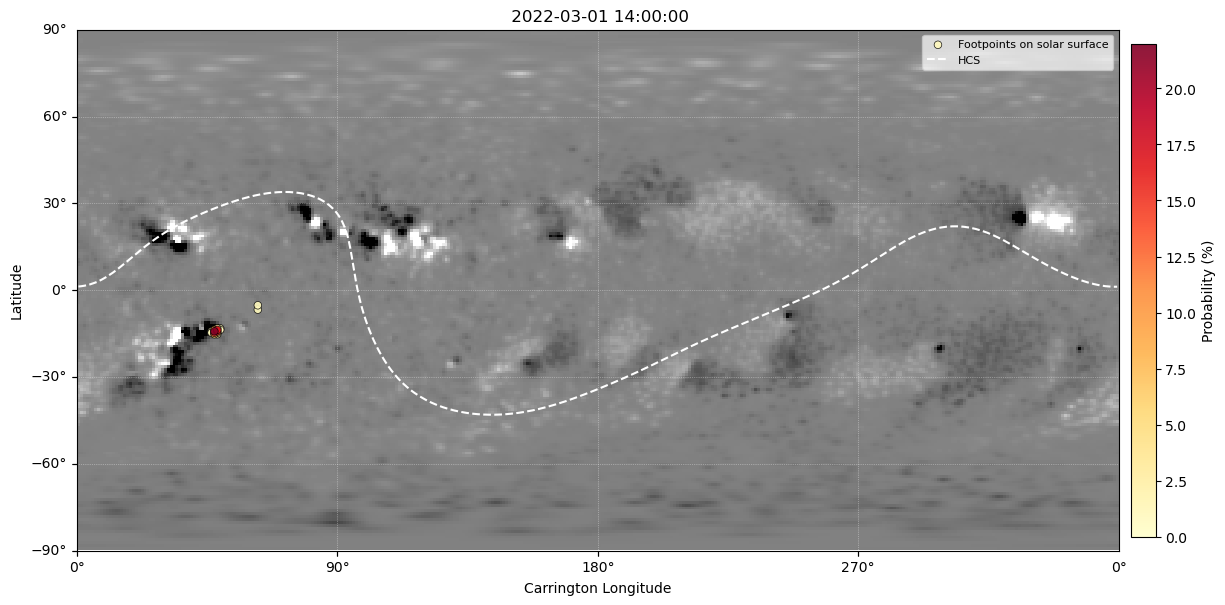

In [84]:
valid_adapt = adapt_data[adapt_data != -9999.0]   # 或用 np.nan 版本
vmin = float(np.percentile(valid_adapt, 0.2)) if float(np.percentile(valid_adapt, 0.2)) > -100 else -100
vmax = float(np.percentile(valid_adapt, 99.8)) if float(np.percentile(valid_adapt, 99.8)) < 100 else 100

plt.close()
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(projection=adapt_map)
im = adapt_map.plot(axes=ax,vmin=vmin,vmax=vmax, cmap='gray')
sorted_idx = temp_df['prob'].argsort().values
ft = ax.scatter_coord(irap_foot_diffrot[sorted_idx], alpha=0.9, vmin=0, vmax=temp_df['prob'].max(),
                      c=temp_df['prob'].values[sorted_idx], cmap='YlOrRd', s=30, edgecolors='k',linewidths=0.5,zorder=6,label="Footpoints on solar surface")

ax.plot_coord(irap_hcs_diffrot, color='white', zorder=4, label="HCS", linestyle='--')
ax.legend(loc="upper right", fontsize=8, framealpha=0.7)
plt.colorbar(ft, ax=ax, label="Probability (%)", shrink=0.8, pad=0.01)

if save_fig:
    fig.savefig(save_dir + f'{SC}_IRAP_{CORONAL}_footpoints_{DATE.replace('-', '')}_{TIME}_(insitu).png', dpi=300)
    print(f'{SC}_IRAP_{CORONAL}_footpoints_{DATE.replace("-", "")}_{TIME}_(insitu).png saved')

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


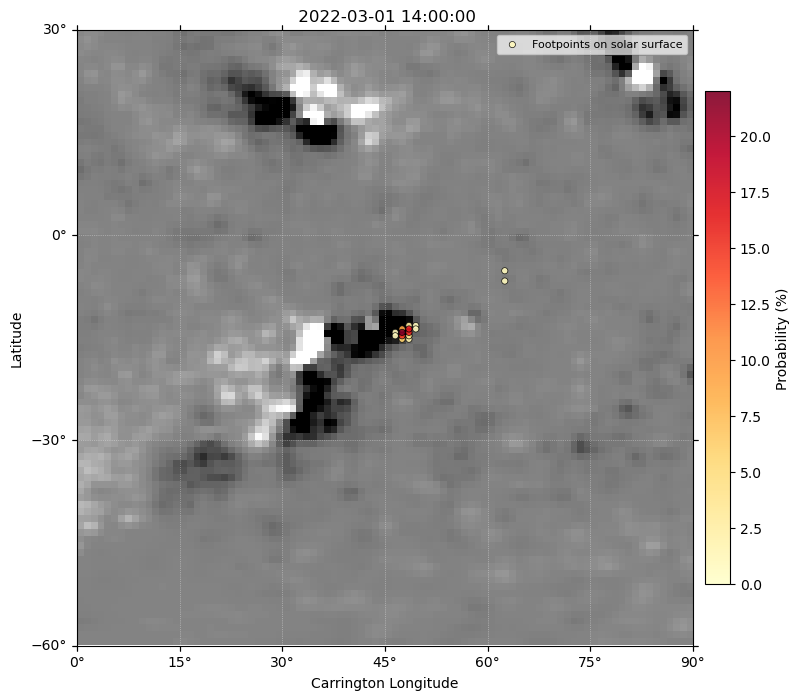

In [85]:
roi_bottom_left = SkyCoord(0*u.deg, -60*u.deg, frame=adapt_map.coordinate_frame)
roi_top_right = SkyCoord(90*u.deg, 30*u.deg, frame=adapt_map.coordinate_frame)
adapt_submap = adapt_map.submap(bottom_left=roi_bottom_left, top_right=roi_top_right)

plt.close()
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(projection=adapt_submap)
im = adapt_submap.plot(axes=ax,vmin=vmin,vmax=vmax, cmap='gray')

ft = ax.scatter_coord(irap_foot_diffrot[sorted_idx], alpha=0.9, vmin=0, vmax=temp_df['prob'].max(),
                      c=temp_df['prob'].values[sorted_idx], cmap='YlOrRd', s=20, edgecolors='k',linewidths=0.5,zorder=6,label="Footpoints on solar surface")


# ax.plot_coord(irap_hcs_diffrot, color='white', zorder=4, label="HCS", linestyle='--')
ax.legend(loc="upper right", fontsize=8, framealpha=0.7)
plt.colorbar(ft, ax=ax, label="Probability (%)", shrink=0.8, pad=0.01)

##### **Plot on AIA & ADAPT**

In [86]:
aia_perp_dir = '/disk/plasma/xw2/sunpy/data/aia_prep/'
aia_prep_map = Map(aia_perp_dir + 'aia_prep_193A_20220301_140004.fits') #aia_prep_193A_20220305_000004, aia_prep_193A_20220301_140004

In [37]:
# # 0. Propagate AIA map to Carrington frame
# from sunpy.map.header_helper import make_heliographic_header

# shape = (720, 1440)
# carr_header = make_heliographic_header(aia_prep_map.date, aia_prep_map.observer_coordinate, shape, frame='carrington')
# carr_header['CRVAL1'] = 180.0

# aia_prep_carr = aia_prep_map.reproject_to(carr_header)

# plt.close()
# fig = plt.figure(figsize=(16, 8))
# ax = fig.add_subplot(projection=aia_prep_carr)
# aia_prep_carr.plot(axes=ax)
# aia_prep_carr.draw_limb(color='blue')


# # 0. Project AIA map to align with ADAPT map. Cautious about the obstime difference
# from sunpy.coordinates import propagate_with_solar_surface

# aia_meta = aia_prep_map.meta.copy()
# aia_meta['rsun_ref'] = 1*u.Rsun.to('m')
# aia_aligned = Map(aia_prep_map.data, aia_meta)

# with propagate_with_solar_surface():
#     aia_on_adapt = aia_aligned.reproject_to(adapt_map.wcs)

# fig = plt.figure(figsize=(10, 5))
# ax = fig.add_subplot(projection=adapt_map)
# aia_on_adapt.plot(axes=ax)

(<matplotlib.patches.Polygon at 0x14cf5c62a850>, None)

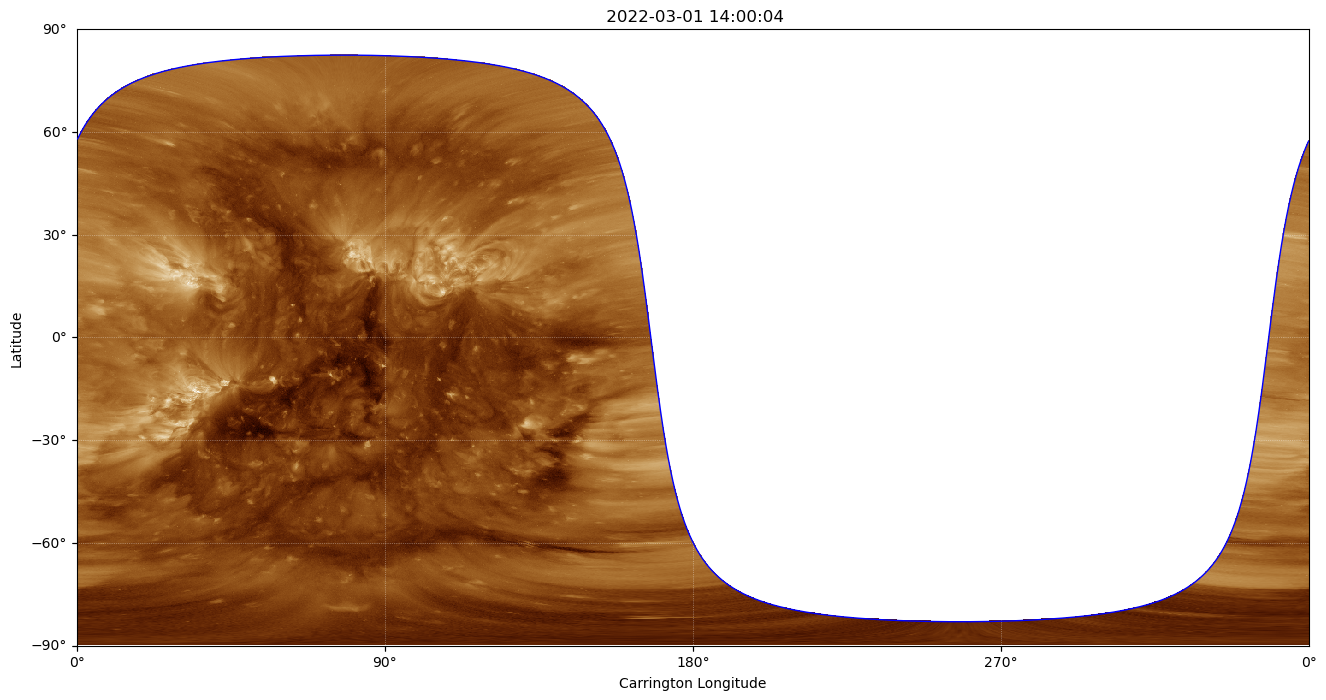

In [87]:
from sunpy.map.header_helper import make_heliographic_header

def make_mag_contour_levels(
    mag_map,
    n_levels: int = 6,
    vmin_percentile: float = 80.0,
    vmax_percentile: float = 99.5,
) -> u.Quantity:
    """
    Generate symmetric, log-spaced contour levels adapted to the actual
    magnetic field range of a given map.
    Parameters
    ----------
    mag_map          : sunpy Map object
    n_levels         : number of positive levels (same for negative side)
    vmin_percentile  : lower bound percentile of |B| for the smallest level
    vmax_percentile  : upper bound percentile of |B| for the largest level
    """
    abs_data = np.abs(mag_map.data[np.isfinite(mag_map.data)])
    nonzero  = abs_data[abs_data > 0]
    v_min = np.percentile(nonzero, vmin_percentile)
    v_max = np.percentile(nonzero, vmax_percentile)
    pos_levels = np.logspace(np.log10(v_min), np.log10(v_max), n_levels)
    all_levels = np.concatenate((-pos_levels[::-1], pos_levels)) * mag_map.unit
    return all_levels

# aia_T_aligned = Map(local_files['193'])

shape = (720, 1440)
carr_header = make_heliographic_header(aia_prep_map.date, aia_prep_map.observer_coordinate, shape, frame='carrington')
carr_header['CRVAL1'] = 180.0

aia_aligned_carr = aia_prep_map.reproject_to(carr_header)

plt.close()
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(projection=aia_aligned_carr)
aia_aligned_carr.plot(axes=ax)
aia_aligned_carr.draw_limb(color='blue')

In [39]:
# mag_level = make_mag_contour_levels(adapt_map) # # mag_level = [20,50, 100, 150, 300, 500] * u.Gauss

# roi_bottom_left = SkyCoord(0*u.deg, -60*u.deg, frame=aia_aligned_carr.coordinate_frame)
# roi_top_right = SkyCoord(90*u.deg, 30*u.deg, frame=aia_aligned_carr.coordinate_frame)
# aia_carr_submap = aia_aligned_carr.submap(bottom_left=roi_bottom_left, top_right=roi_top_right)
# adapt_submap = adapt_map.submap(bottom_left=roi_bottom_left, top_right=roi_top_right)

# plt.close()
# fig = plt.figure(figsize=(16, 8))
# ax = fig.add_subplot(projection=aia_carr_submap)
# aia_carr_submap.plot(axes=ax)
# bound = ax.axis()

# cset=adapt_submap.draw_contours(levels=mag_level, axes=ax, cmap='seismic', alpha=0.4)
# ax.axis(bound)

# irap_foot_diffrot2 = SkyCoord(RotatedSunFrame(base=irap_foot, duration=(aia_aligned_carr.date - irap_foot.obstime).to(u.hour)))
# ft = ax.scatter_coord(irap_foot_diffrot2[sorted_idx], alpha=0.9, vmin=0, vmax=temp_df['prob'].max(), marker='X',
#                       c=temp_df['prob'].values[sorted_idx], cmap='YlOrRd', s=20, edgecolors='k',linewidths=0.5,zorder=6,label="Footpoints on solar surface")

# ax.legend(loc="upper right", fontsize=8, framealpha=0.7)

# cb_mag  = fig.colorbar(cset, ax=ax, shrink=0.8, pad=0.06,  fraction=0.025,
#                         label=f"Magnetic Field Strength [{adapt_map.unit}]",
#                         ticks=list(mag_level.value) + [0])
# cb_prob = fig.colorbar(ft,   ax=ax, shrink=0.8, pad=0.01,  fraction=0.025,
#                         label="Probability (%)")

# plt.show()

In [40]:
# # mag_level = make_mag_contour_levels(adapt_map) # # mag_level = [20,50, 100, 150, 300, 500] * u.Gauss

# roi_bottom_left = SkyCoord(0*u.deg, -60*u.deg, frame=aia_aligned_carr.coordinate_frame)
# roi_top_right = SkyCoord(90*u.deg, 30*u.deg, frame=aia_aligned_carr.coordinate_frame)
# aia_carr_submap = aia_aligned_carr.submap(bottom_left=roi_bottom_left, top_right=roi_top_right)
# adapt_submap = adapt_map.submap(bottom_left=roi_bottom_left, top_right=roi_top_right)

# plt.close()
# fig = plt.figure(figsize=(16, 8))
# ax = fig.add_subplot(projection=aia_carr_submap)


# aia_carr_submap.plot(axes=ax,alpha=1, zorder=1)
# bound = ax.axis()

# # cset=adapt_submap.draw_contours(levels=mag_level, axes=ax, cmap='seismic', alpha=0.4)
# im = adapt_submap.plot(axes=ax,vmin=vmin,vmax=vmax, cmap='gray',alpha=0.35, zorder=2)
# ax.axis(bound)

# ax.set_title(f'{aia_carr_submap.date.strftime('%Y-%m-%d %H:%M:%S')}')

# irap_foot_diffrot2 = SkyCoord(RotatedSunFrame(base=irap_foot, duration=(aia_aligned_carr.date - irap_foot.obstime).to(u.hour)))
# ft = ax.scatter_coord(irap_foot_diffrot2[sorted_idx], alpha=0.9, vmin=0, vmax=temp_df['prob'].max(), marker='X',
#                       c=temp_df['prob'].values[sorted_idx], cmap='YlOrRd', s=20, edgecolors='k',linewidths=0.5,zorder=6,label="Footpoints on solar surface")

# ax.legend(loc="upper right", fontsize=8, framealpha=0.7)
# cb_prob = fig.colorbar(ft,   ax=ax, shrink=0.8, pad=0.01,  fraction=0.025,
#                         label="Probability (%)")
# # cb_mag  = fig.colorbar(cset, ax=ax, shrink=0.8, pad=0.06,  fraction=0.025,
# #                         label=f"Magnetic Field Strength [{adapt_map.unit}]",
# #                         ticks=list(mag_level.value) + [0])

# plt.show()

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Using image-based autoalignment [sunpy.map.mapbase]


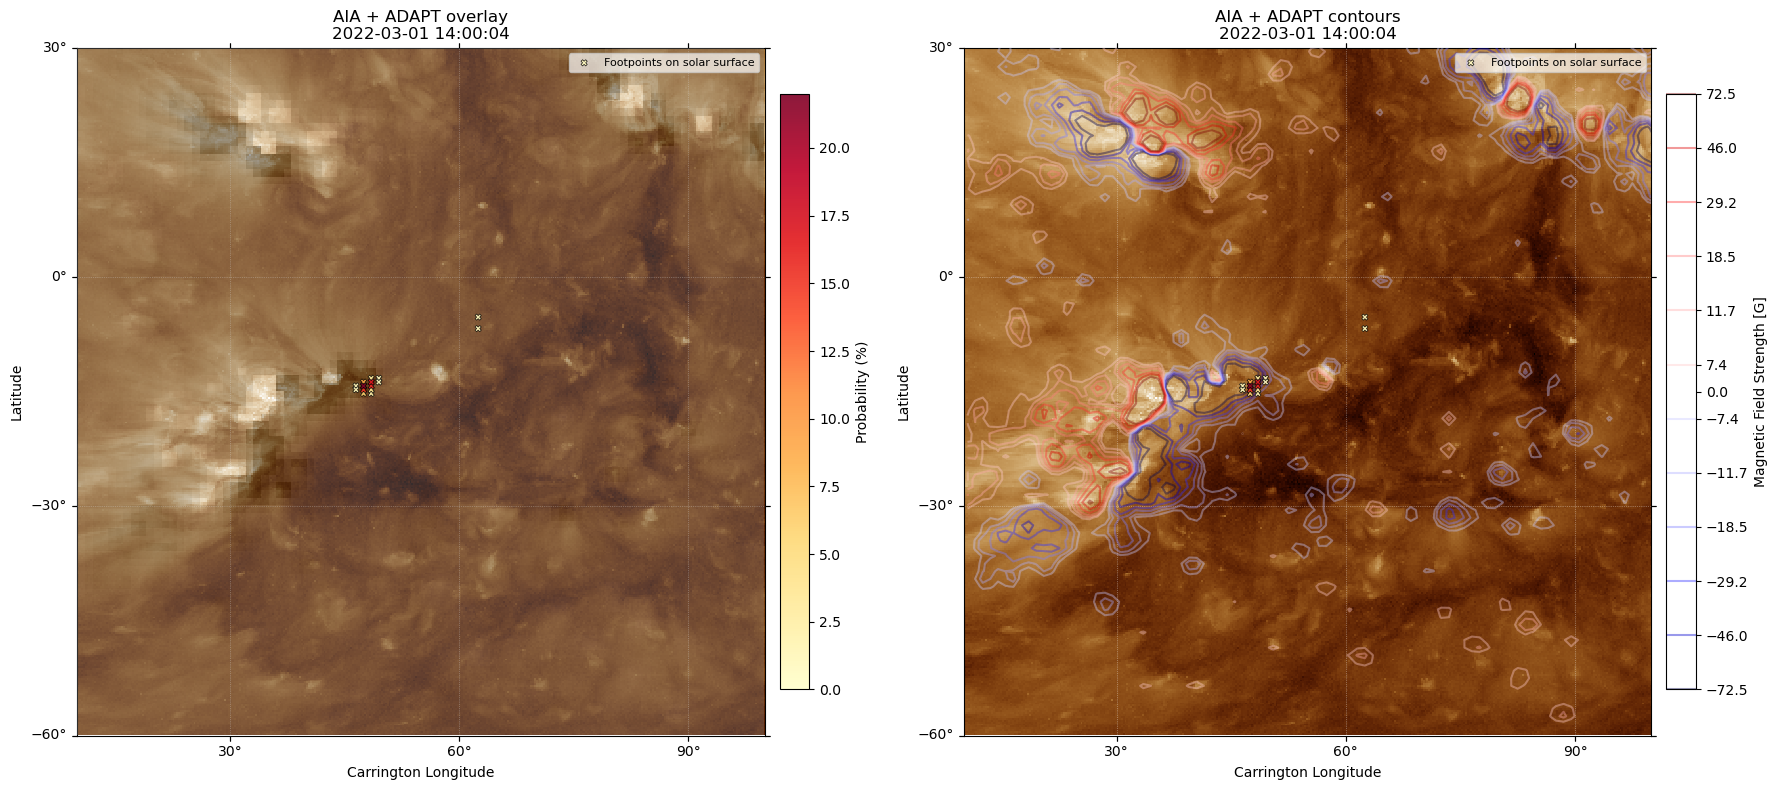

In [88]:
roi_bottom_left = SkyCoord(10*u.deg, -60*u.deg, frame=aia_aligned_carr.coordinate_frame)
roi_top_right = SkyCoord(100*u.deg, 30*u.deg, frame=aia_aligned_carr.coordinate_frame)
aia_carr_submap = aia_aligned_carr.submap(bottom_left=roi_bottom_left, top_right=roi_top_right)
adapt_submap = adapt_map.submap(bottom_left=roi_bottom_left, top_right=roi_top_right) # only use this when adapt & aia have the same date

# adapt_reproj = adapt_map.reproject_to(aia_aligned_carr.wcs)
# # restore the unit lost during reprojection
# new_meta = adapt_reproj.meta.copy()
# new_meta['bunit'] = str(adapt_map.unit)
# adapt_reproj = Map(adapt_reproj.data, new_meta)
# adapt_submap = adapt_reproj.submap(bottom_left=roi_bottom_left, top_right=roi_top_right)

# ADAPT mag contour levels
mag_level = make_mag_contour_levels(adapt_map) # # mag_level = [20,50, 100, 150, 300, 500] * u.Gauss

# Match time of ft with aia_map, using differential rotation 
irap_foot_diffrot2 = SkyCoord(RotatedSunFrame(base=irap_foot, duration=(aia_aligned_carr.date - irap_foot.obstime).to(u.hour)))

plt.close()
fig = plt.figure(figsize=(18, 8))

# ── Left panel: AIA + ADAPT overlay ──────────────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1, projection=aia_carr_submap)
aia_carr_submap.plot(axes=ax1, alpha=1, zorder=1)
bound1 = ax1.axis()
adapt_submap.plot(axes=ax1, vmin=vmin, vmax=vmax, cmap='gray', alpha=0.35, zorder=2)
ax1.axis(bound1)

ft1 = ax1.scatter_coord(
    irap_foot_diffrot2[sorted_idx], alpha=0.9,
    vmin=0, vmax=temp_df['prob'].max(), marker='X',
    c=temp_df['prob'].values[sorted_idx], cmap='YlOrRd',
    s=20, edgecolors='k', linewidths=0.5, zorder=6,
    label="Footpoints on solar surface"
)
ax1.legend(loc="upper right", fontsize=8, framealpha=0.7)
ax1.set_title(f"AIA + ADAPT overlay\n{aia_carr_submap.date.strftime('%Y-%m-%d %H:%M:%S')}")
fig.colorbar(ft1, ax=ax1, shrink=1, pad=0.02, fraction=0.04,
             label="Probability (%)")

# ── Right panel: AIA + magnetic field contours ────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2, projection=aia_carr_submap)
aia_carr_submap.plot(axes=ax2)
bound2 = ax2.axis()

cset = adapt_submap.draw_contours(levels=mag_level, axes=ax2, cmap='seismic', alpha=0.4)
ax2.axis(bound2)

ft2 = ax2.scatter_coord(
    irap_foot_diffrot2[sorted_idx], alpha=0.9,
    vmin=0, vmax=temp_df['prob'].max(), marker='X',
    c=temp_df['prob'].values[sorted_idx], cmap='YlOrRd',
    s=20, edgecolors='k', linewidths=0.5, zorder=6,
    label="Footpoints on solar surface"
)
ax2.legend(loc="upper right", fontsize=8, framealpha=0.7)
ax2.set_title(f"AIA + ADAPT contours\n{aia_carr_submap.date.strftime('%Y-%m-%d %H:%M:%S')}")
fig.colorbar(cset, ax=ax2, fraction=0.04, shrink=1, pad=0.02, 
             label=f"Magnetic Field Strength [{adapt_map.unit}]",
             ticks=list(mag_level.value) + [0])
# fig.colorbar(ft2, ax=ax2, shrink=0.8, pad=0.01, fraction=0.025,
#              label="Probability (%)")


plt.subplots_adjust(wspace=0.05)
plt.tight_layout()
plt.show()
if save_fig:
    fig.savefig(save_dir+f'AIA_ADAPT_overlay_SUNTIME_{aia_carr_submap.date.strftime("%Y%m%d_%H%M%S")}.png', dpi=300)
    print(f'AIA_ADAPT_overlay_SUNTIME_{aia_carr_submap.date.strftime("%Y%m%d_%H%M%S")}.png saved')

##### **DEM iamges**

In [89]:
filtered_df = (foot_solarsurf_df[foot_solarsurf_df['type'] == sw_type].sort_values('prob', ascending=False)
    .reset_index(drop=True))
filtered_df['cumulative_prob'] = filtered_df['prob'].cumsum()
dominant_ft_df = filtered_df[filtered_df['cumulative_prob'].shift(1, fill_value=0) < 60]

# compute the ft position 
dominant_ft = SkyCoord(dominant_ft_df['lon_CR'].values*u.deg, dominant_ft_df['lat_CR'].values*u.deg, dominant_ft_df['R_m'].values*u.m,
                     obstime=params['metadata']['date_surf'], frame=HeliographicCarrington,
                     observer=adapt_map.observer_coordinate)
dominant_ft_diffrot = SkyCoord(RotatedSunFrame(base=dominant_ft, rotated_time=aia_aligned_carr.date)) #.transform_to(aia_aligned_carr.coordinate_frame)

In [ ]:
# save dominant_ft
from pathlib import Path as FilePath
from astropy.table import QTable

PROB_THRESHOLD_PCT = 60



dateSurfTag = pd.to_datetime(str(params['metadata']['date_surf'])).strftime('%Y%m%dT%H%M%S')
swTypeTag = str(sw_type).replace('/', '-').replace(' ', '')
scTag = str(params.get('sc_name', 'sc')).replace(' ', '').replace('/', '-')
coronalTag = str(params['metadata'].get('coronal_model', '')).replace(' ', '')
realizationTag = str(params['metadata'].get('realization_adapt', ''))

fileStem = (
    f"dominant_ft_{scTag}_{swTypeTag}"
    f"_surf{dateSurfTag}"
    f"_{coronalTag}_r{realizationTag}"
    f"_prob{PROB_THRESHOLD_PCT}"
)
savePath = save_dir + f"{fileStem}.ecsv"

# ECSV can't serialize a full observer SkyCoord inside a frame attribute, so
# store lon/lat/radius as plain Quantity columns and flatten the frame /
# observer / obstime info into meta. Load side rebuilds the SkyCoord.
observerFrame = dominant_ft.observer

footTable = QTable({
    'lon': dominant_ft.lon.to(u.deg),
    'lat': dominant_ft.lat.to(u.deg),
    'radius': dominant_ft.radius.to(u.m),
    'prob': np.asarray(dominant_ft_df['prob'].values, dtype=float),
    'cumulative_prob': np.asarray(dominant_ft_df['cumulative_prob'].values, dtype=float),
    'type': np.asarray(dominant_ft_df['type'].values, dtype=str),
})

footTable.meta.update({
    # provenance
    'sc_name':           str(params.get('sc_name', '')),
    'sw_type':           str(sw_type),
    'date_surf':         str(params['metadata']['date_surf']),
    'date_insitu':       str(params['metadata'].get('date_insitu', '')),
    'prob_threshold_pct': PROB_THRESHOLD_PCT,
    'coronal_model':     params['metadata'].get('coronal_model'),
    'mag_input':         params['metadata'].get('mag_input'),
    'realization_adapt': params['metadata'].get('realization_adapt'),
    'helio_model':       params['metadata'].get('helio_model'),
    'source_surface_Rsun': params['metadata'].get('source_surface_Rsun'),
    # coordinate frame (how to rebuild SkyCoord on load)
    'frame':             'HeliographicCarrington',
    'obstime':           str(dominant_ft.obstime),
    'rsun_m':            float(dominant_ft.frame.rsun.to_value(u.m)),
    # observer (flattened HeliographicStonyhurst)
    'observer_frame':    'HeliographicStonyhurst',
    'observer_obstime':  str(observerFrame.obstime),
    'observer_lon_deg':  float(observerFrame.lon.to_value(u.deg)),
    'observer_lat_deg':  float(observerFrame.lat.to_value(u.deg)),
    'observer_radius_m': float(observerFrame.radius.to_value(u.m)),
    'observer_rsun_m':   float(observerFrame.rsun.to_value(u.m)),
    'note': (
        'Dominant PFSS footpoints at date_surf in HGC with ADAPT observer. '
        'Rebuild SkyCoord via: '
        'observer=SkyCoord(lon=meta["observer_lon_deg"]*u.deg, lat=meta["observer_lat_deg"]*u.deg, '
        'radius=meta["observer_radius_m"]*u.m, frame=HeliographicStonyhurst, '
        'obstime=meta["observer_obstime"]); '
        'coord=SkyCoord(tbl["lon"], tbl["lat"], tbl["radius"], frame=HeliographicCarrington, '
        'obstime=meta["obstime"], observer=observer). '
        'For another epoch t1 use SkyCoord(RotatedSunFrame(base=coord, rotated_time=t1)).'
    ),
})

footTable.write(savePath, format='ascii.ecsv', overwrite=True)
print(f'Saved {len(footTable)} dominant footpoints -> {savePath}')


# Read footpoints
# from astropy.table import QTable
# from astropy.coordinates import SkyCoord
# from astropy import units as u
# from sunpy.coordinates import HeliographicCarrington, HeliographicStonyhurst, RotatedSunFrame
# tbl = QTable.read('../results/IRAP_results/2022-03-06/dominant_ft_SOLO_SSW_surf20220304T235511_PFSS_r1_prob60.ecsv')
# meta = tbl.meta

# observer_read = SkyCoord(
#     lon=meta['observer_lon_deg'] * u.deg,
#     lat=meta['observer_lat_deg'] * u.deg,
#     radius=meta['observer_radius_m'] * u.m,
#     frame=HeliographicStonyhurst,
#     obstime=meta['observer_obstime'],
# )

# dominant_ft_0306 = SkyCoord(
#     tbl['lon'], tbl['lat'], tbl['radius'],
#     frame=HeliographicCarrington,
#     obstime=meta['obstime'],
#     observer=observer_read,
#     # rsun=meta['rsun_m']*u.m,   # 可选，默认值通常也够
# )

# # # 需要画到另一张 AIA 图上：
# # dominant_ft_diffrot = SkyCoord(
# #     RotatedSunFrame(base=dominant_ft, rotated_time=aia_map.date)
# # )
# dominant_ft_0306_diffrot = SkyCoord(RotatedSunFrame(base=dominant_ft_0306, rotated_time=aia_carr_submap.date))

In [90]:
from scipy.spatial import ConvexHull
from matplotlib.path import Path

# **************  new sub region  **************
lon_bl, lat_bl = 30, -30 # 0306:[40,-30] #0303:[30,-30]
lon_tr, lat_tr = 60, 0 # 0306:[70, 0] #0303:[60, 0]

roi_bottom_left = SkyCoord(lon_bl*u.deg, lat_bl*u.deg, frame=aia_aligned_carr.coordinate_frame) 
roi_top_right = SkyCoord(lon_tr*u.deg, lat_tr*u.deg, frame=aia_aligned_carr.coordinate_frame) 
aia_carr_submap = aia_aligned_carr.submap(bottom_left=roi_bottom_left, top_right=roi_top_right)
adapt_submap = adapt_map.submap(bottom_left=roi_bottom_left, top_right=roi_top_right)

lons = dominant_ft_diffrot.lon.deg
lats = dominant_ft_diffrot.lat.deg
hull = ConvexHull(np.column_stack([lons, lats]))
# Close the polygon by appending the first vertex at the end
hull_lons = np.append(lons[hull.vertices], lons[hull.vertices[0]])
hull_lats = np.append(lats[hull.vertices], lats[hull.vertices[0]])
hull_coords = SkyCoord(hull_lons * u.deg, hull_lats * u.deg, frame=aia_aligned_carr.coordinate_frame)

hull_boundary = np.column_stack([hull_lons[:-1], hull_lats[:-1]])
hull_path = Path(hull_boundary)

ny, nx = aia_carr_submap.data.shape
y_idx, x_idx = np.mgrid[0:ny, 0:nx]

world = aia_carr_submap.wcs.pixel_to_world(x_idx.ravel(), y_idx.ravel()) # aia_carr_submap 全图像素对应的 lon/lat
pix_lonlat = np.column_stack([world.lon.deg, world.lat.deg])

inside_AIApix_mask = hull_path.contains_points(pix_lonlat)
inside_lon = world.lon.deg[inside_AIApix_mask]
inside_lat = world.lat.deg[inside_AIApix_mask]
# region_values = aia_carr_submap.data[inside_AIApix_mask]
print(f"Pixels inside hull: {inside_AIApix_mask.sum()}")

Pixels inside hull: 8


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


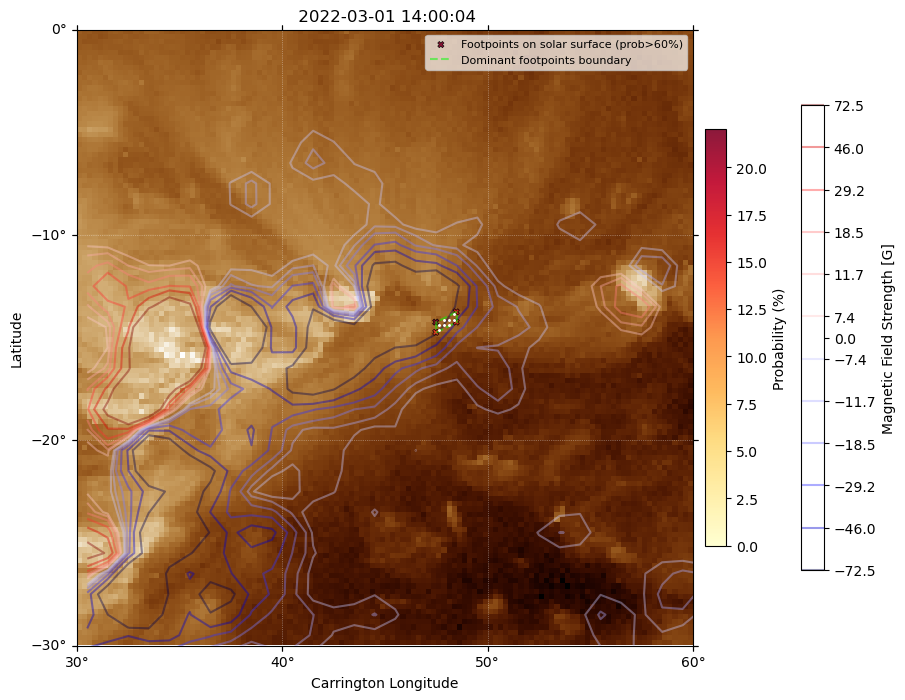

In [91]:
mag_level = make_mag_contour_levels(adapt_map) # # mag_level = [20,50, 100, 150, 300, 500] * u.Gauss

plt.close()
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection=aia_carr_submap)
aia_carr_submap.plot(axes=ax)
bound = ax.axis()

cset=adapt_submap.draw_contours(levels=mag_level, axes=ax, cmap='seismic', alpha=0.4)
ax.axis(bound)


ft = ax.scatter_coord(dominant_ft, alpha=0.9, marker='X', s=20,
                      vmin=0, vmax=dominant_ft_df['prob'].max(), 
                      c=dominant_ft_df['prob'].values, cmap='YlOrRd', edgecolors='k',linewidths=0.5,zorder=6,label="Footpoints on solar surface (prob>60%)")
ax.plot_coord(hull_coords, color='lime', linewidth=1.5, linestyle='--', zorder=7, alpha=0.5,
              label="Dominant footpoints boundary")

inside_y, inside_x = np.where(inside_AIApix_mask.reshape(ny, nx))
ax.scatter(inside_x, inside_y, marker='.', s=5, color='white', linewidths=1, zorder=8)

ax.legend(loc="upper right", fontsize=8, framealpha=0.7)

cb_mag  = fig.colorbar(cset, ax=ax, fraction=0.025,shrink=0.8, pad=0.08,  
                        label=f"Magnetic Field Strength [{adapt_map.unit}]",
                        ticks=list(mag_level.value) + [0])
cb_prob = fig.colorbar(ft,   ax=ax, fraction=0.025,shrink=0.8, pad=0.015,  
                        label="Probability (%)")

# plt.tight_layout()
if save_fig:
    fig.savefig(save_dir + f'{SC}_IRAP_{CORONAL}_SourceRegion_{DATE.replace('-', '')}_{TIME}_(insitu).png', dpi=300)
plt.show()

In [ ]:
dem_dir = '../results/DEM/2022-03-01/'
T_mean_map = Map(dem_dir + 'T_mean_map_20220301_140000.fits') #T_mean_map_20220305_000000 T_mean_map_20220301_140000.fits


## ****** Interpolate NaN pixels in a 2D array using surrounding valid values ******
# from scipy.interpolate import griddata
# def fill_nan_2d(data, method="linear"):
#     """Interpolate NaN pixels in a 2D array using surrounding valid values."""
#     filled = np.asarray(data, dtype=float).copy()
#     nan_mask = np.isnan(filled)
#     if not nan_mask.any():
#         return filled

#     ny, nx = filled.shape
#     yy, xx = np.mgrid[0:ny, 0:nx]
#     valid_points = np.column_stack((yy[~nan_mask], xx[~nan_mask]))
#     valid_values = filled[~nan_mask]

#     filled[nan_mask] = griddata(
#         valid_points,
#         valid_values,
#         np.column_stack((yy[nan_mask], xx[nan_mask])),
#         method=method,
#     )

#     # Linear interpolation leaves NaN outside the convex hull; fallback to nearest.
#     still_nan = np.isnan(filled)
#     if still_nan.any():
#         filled[still_nan] = griddata(
#             valid_points,
#             valid_values,
#             np.column_stack((yy[still_nan], xx[still_nan])),
#             method="nearest",
#         )
#     return filled

# T_mean_filled = fill_nan_2d(T_mean_map.data, method="linear")
# print(f"Filled {np.isnan(T_mean_map.data).sum()} NaN pixels "
#       f"(remaining NaN: {np.isnan(T_mean_filled).sum()})")


# # 计算新数据
# new_data = np.where(
#     T_mean_map.data > 0,
#     T_mean_map.data,
#     np.min(T_mean_map.data[T_mean_map.data > 0])
# )

# 用新数据和原来的 header/meta 创建新的 Map
T_mean_map = Map(T_mean_map.data, T_mean_map.meta) #(new_data, T_mean_map.meta)

In [108]:
from sunpy.map import make_fitswcs_header
from astropy.wcs import WCS

ny_hires, nx_hires = T_mean_map.data.shape

roi_center = SkyCoord(
    0.5*(lon_bl+lon_tr)*u.deg, 0.5*(lat_bl+lat_tr)*u.deg,               # ROI 中心 (30+60)/2, (-30+0)/2
    frame=HeliographicCarrington,
    obstime=T_mean_map.date,
    observer=T_mean_map.observer_coordinate
)

hires_header = make_fitswcs_header(
    (ny_hires, nx_hires),
    roi_center,
    scale=u.Quantity([(30.0 / nx_hires), (30.0 / ny_hires)], u.deg/u.pix),
    projection_code='CAR'
)

out_wcs = WCS(hires_header)
out_wcs.array_shape = (ny_hires, nx_hires)
T_mean_carr = T_mean_map.reproject_to(out_wcs)

INFO: Using mesh-based autoalignment [sunpy.map.mapbase]


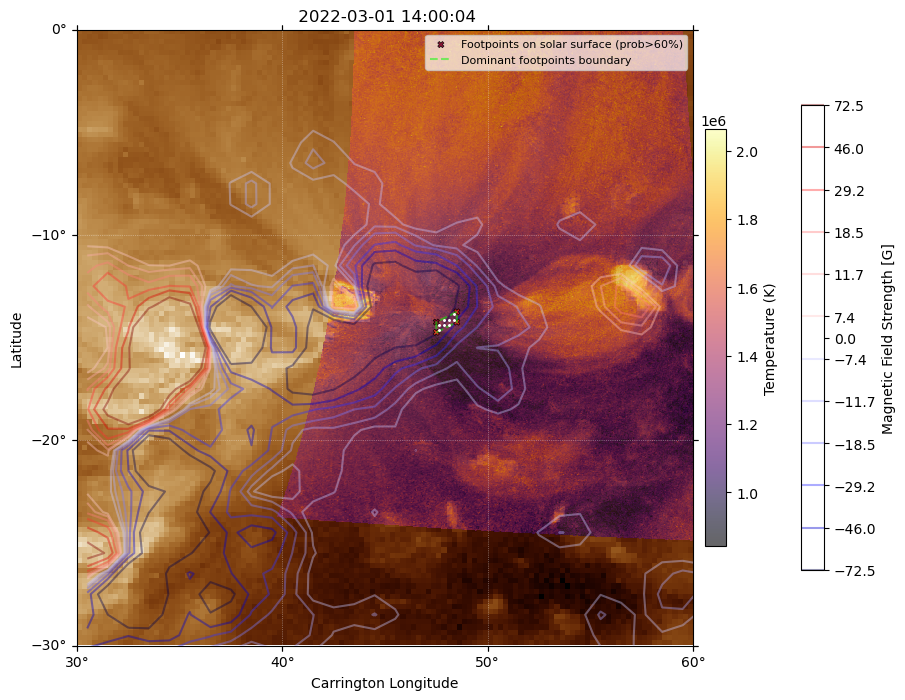

In [109]:
plt.close()
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection=aia_carr_submap)
aia_carr_submap.plot(axes=ax)
bound = ax.axis()

cset=adapt_submap.draw_contours(levels=mag_level, axes=ax, cmap='seismic', alpha=0.4)

Tmap = T_mean_carr.plot(axes=ax, cmap='inferno',alpha=0.6, origin='lower')
ax.axis(bound)


ft = ax.scatter_coord(dominant_ft_diffrot, alpha=0.9, marker='X', s=20,
                      vmin=0, vmax=dominant_ft_df['prob'].max(), 
                      c=dominant_ft_df['prob'].values, cmap='YlOrRd', edgecolors='k',linewidths=0.5,zorder=6,label="Footpoints on solar surface (prob>60%)")
ax.plot_coord(hull_coords, color='lime', linewidth=1.5, linestyle='--', zorder=7, alpha=0.5,
              label="Dominant footpoints boundary")

inside_y, inside_x = np.where(inside_AIApix_mask.reshape(ny, nx))
ax.scatter(inside_x, inside_y, marker='.', s=5, color='white', linewidths=1, zorder=8)

ax.legend(loc="upper right", fontsize=8, framealpha=0.7)

cb_mag  = fig.colorbar(cset, ax=ax, fraction=0.025,shrink=0.8, pad=0.08,  
                        label=f"Magnetic Field Strength [{adapt_map.unit}]",
                        ticks=list(mag_level.value) + [0])
# cb_prob = fig.colorbar(ft,   ax=ax, fraction=0.025,shrink=0.8, pad=0.015,  
#                         label="Probability (%)")
cbar = fig.colorbar(Tmap, ax=ax, fraction=0.025,shrink=0.8, pad=0.015,  
                        label="Temperature (K)")

# plt.tight_layout()
# fig.savefig(save_dir + f'{SC}_DEM_Tmean_IRAP_{CORONAL}_SourceRegion_{DATE.replace('-', '')}_{TIME}_(insitu).png', dpi=300)
plt.show()

In [110]:
ny_t, nx_t = T_mean_carr.data.shape
y_idx_t, x_idx_t = np.mgrid[0:ny_t, 0:nx_t]

world_t = T_mean_carr.wcs.pixel_to_world(x_idx_t.ravel(), y_idx_t.ravel())
T_pix_lonlat = np.column_stack([world_t.lon.deg, world_t.lat.deg])

inside_Tpix_mask_flat = hull_path.contains_points(T_pix_lonlat)
inside_Tpix_mask = inside_Tpix_mask_flat.reshape(ny_t, nx_t)

valid_mask = inside_Tpix_mask & np.isfinite(T_mean_carr.data)

T_inside_values = T_mean_carr.data[valid_mask]
T_inside_lon = world_t.lon.deg.reshape(ny_t, nx_t)[valid_mask]
T_inside_lat = world_t.lat.deg.reshape(ny_t, nx_t)[valid_mask]

print(f"T_mean pixels inside hull: {valid_mask.sum()} "
      f"(total in hull: {inside_Tpix_mask.sum()}, "
      f"NaN excluded: {inside_Tpix_mask.sum() - valid_mask.sum()})")

T_mean pixels inside hull: 856 (total in hull: 856, NaN excluded: 0)


In [112]:
type(T_inside_values)
# 保存 T_inside_values 及对应的 lon, lat 到一个 npz 文件
np.savez(
    save_dir + f"{SC}_T(kelvin)_of_source_region_{DATE.replace('-', '')}_{TIME}.npz",
    values=T_inside_values,
    lon=T_inside_lon,
    lat=T_inside_lat
)

In [101]:
T_inside_values.mean()

np.float64(1179463.7450363003)

In [111]:
T_inside_values.mean()

np.float64(1212866.5273314638)

In [113]:
npz_file = np.load('../results/IRAP_results/2022-03-06/SOLO_T(kelvin)_of_source_region_20220306_180000.npz')
T_0306 = npz_file['values']
T_0306.mean()

np.float64(1643722.2023828889)